In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/student.csv", sep=";")
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
df.shape


(395, 33)

In [5]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
df["avg_grade"] = df[["G1", "G2", "G3"]].mean(axis=1)
df[["G1", "G2", "G3", "avg_grade"]].head()

,G1,G2,G3,avg_grade
0,5,6,6,5.666667
1,5,5,6,5.333333
2,7,8,10,8.333333
3,15,14,15,14.666667
4,6,10,10,8.666667


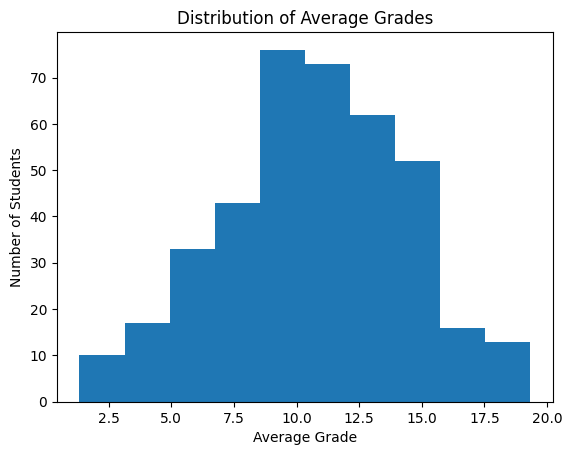

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["avg_grade"], bins=10)
plt.title("Distribution of Average Grades")
plt.xlabel("Average Grade")
plt.ylabel("Number of Students")
plt.show()

In [8]:
df["famsup_num"] = df["famsup"].map({"yes": 1, "no": 0})
df[["famsup", "famsup_num"]].head()

,famsup,famsup_num
0,no,0
1,yes,1
2,no,0
3,yes,1
4,yes,1


In [9]:
df["study_score"] = df["studytime"] * 2
df[["studytime", "study_score"]].head()

,studytime,study_score
0,2,4
1,2,4
2,2,4
3,3,6
4,2,4


In [10]:
df["attendance_score"] = np.where(
    df["absences"] < 5, 10,
    np.where(df["absences"] < 10, 5, 0)
)

df[["absences", "attendance_score"]].head()


,absences,attendance_score
0,6,5
1,4,10
2,10,0
3,2,10
4,4,10


In [11]:
df["failure_penalty"] = df["failures"] * -5
df[["failures", "failure_penalty"]].head()

,failures,failure_penalty
0,0,0
1,0,0
2,3,-15
3,0,0
4,0,0


In [12]:
df["risk_score"] = (
    df["study_score"] +
    df["attendance_score"] +
    df["failure_penalty"] +
    df["famsup_num"] * 2
)

df[[
    "study_score",
    "attendance_score",
    "failure_penalty",
    "famsup_num",
    "risk_score"
]].head()

,study_score,attendance_score,failure_penalty,famsup_num,risk_score
0,4,5,0,0,9
1,4,10,0,1,16
2,4,0,-15,0,-11
3,6,10,0,1,18
4,4,10,0,1,16


In [13]:
def categorize_risk(score):
    if score <= 5:
        return "High Risk"
    elif score <= 10:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_level"] = df["risk_score"].apply(categorize_risk)
df["risk_level"].value_counts()


risk_level
Low Risk       243
Medium Risk     77
High Risk       75
Name: count, dtype: int64

In [14]:
df[[
    "avg_grade",
    "risk_score",
    "risk_level"
]].sort_values("risk_score").head(10)


,avg_grade,risk_score,risk_level
247,7.333333,-13,High Risk
2,8.333333,-11,High Risk
18,5.333333,-11,High Risk
350,7.666667,-6,High Risk
216,5.333333,-6,High Risk
25,7.666667,-6,High Risk
157,9.000000,-6,High Risk
270,9.000000,-4,High Risk
314,13.666667,-4,High Risk
206,7.000000,-4,High Risk


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

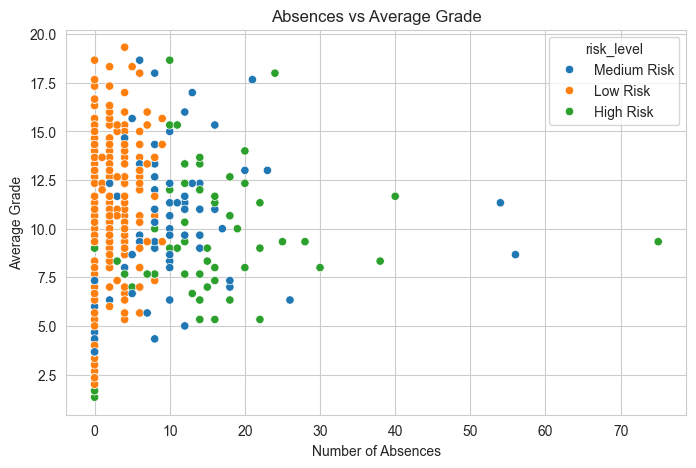

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="absences",
    y="avg_grade",
    hue="risk_level"
)
plt.title("Absences vs Average Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Average Grade")
plt.show()


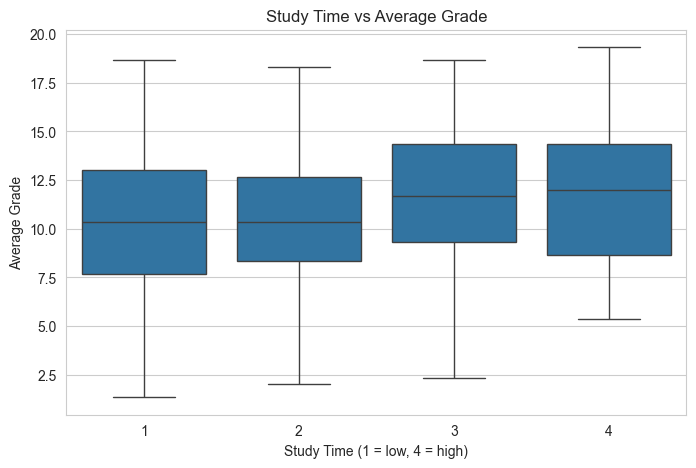

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="studytime",
    y="avg_grade"
)
plt.title("Study Time vs Average Grade")
plt.xlabel("Study Time (1 = low, 4 = high)")
plt.ylabel("Average Grade")
plt.show()

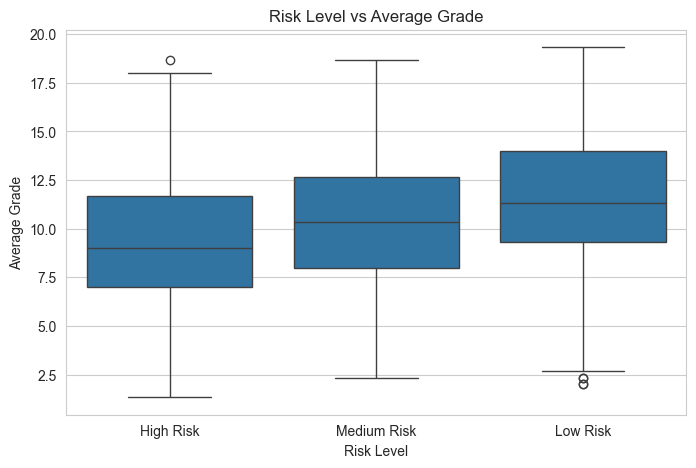

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="risk_level",
    y="avg_grade",
    order=["High Risk", "Medium Risk", "Low Risk"]
)
plt.title("Risk Level vs Average Grade")
plt.xlabel("Risk Level")
plt.ylabel("Average Grade")
plt.show()

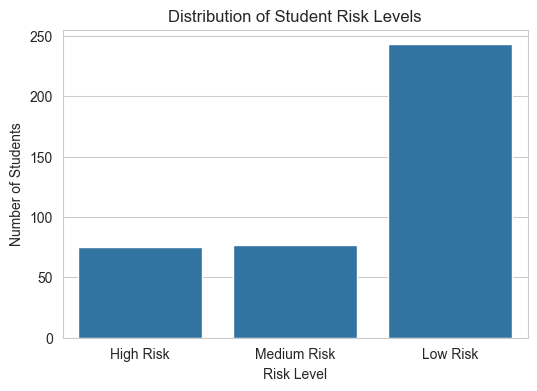

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="risk_level",
    order=["High Risk", "Medium Risk", "Low Risk"]
)
plt.title("Distribution of Student Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.show()


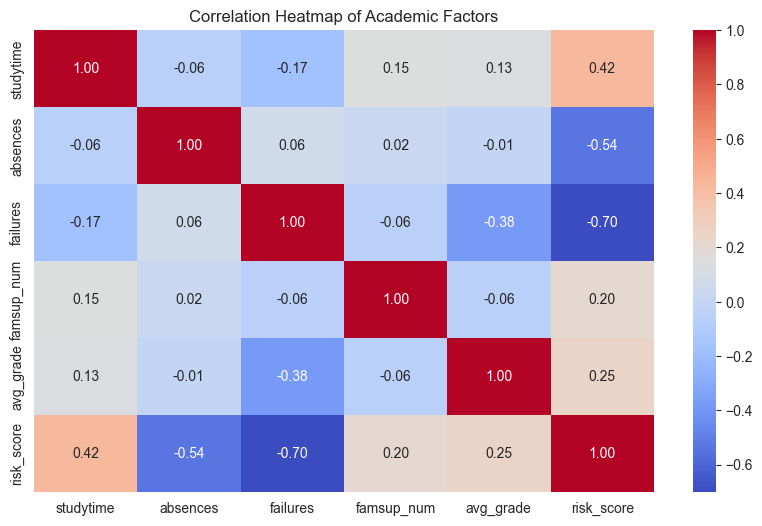

In [20]:
plt.figure(figsize=(10,6))

numeric_cols = [
    "studytime",
    "absences",
    "failures",
    "famsup_num",
    "avg_grade",
    "risk_score"
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Academic Factors")
plt.show()

In [21]:
high_risk_students = df[df["risk_level"] == "High Risk"]

high_risk_students[
    ["studytime", "absences", "failures", "avg_grade", "risk_score"]
].head(10)


,studytime,absences,failures,avg_grade,risk_score
2,2,10,3,8.333333,-11
18,1,16,3,5.333333,-11
25,1,14,2,7.666667,-6
40,2,25,1,9.333333,1
44,2,14,1,9.666667,-1
52,1,6,1,10.666667,2
78,1,2,3,8.666667,-1
85,2,6,2,8.000000,-1
88,2,12,1,10.333333,-1
100,1,14,0,6.333333,4
